# Examples for McKean-Vlasov control

In [1]:
from main import McKeanVlasovSolver
from main import McKeanVlasovPlotter
from fourier_utils import FourierUtils
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

from scipy.special import beta
from scipy.special import iv as bessel
from scipy.optimize import brentq
from scipy.linalg import eig
from scipy.linalg import cholesky, solve
from tqdm import tqdm

import scienceplots
plt.style.use('science')

In [2]:
%load_ext autoreload
%autoreload 2

## Initial distributions

In [3]:
def mu_0(x):
    alpha_param = 2.0
    beta_param = 2.0
    Z = (2 * np.pi)**(alpha_param + beta_param - 1) * beta(alpha_param, beta_param)
    return (x**(alpha_param - 1) * (2 * np.pi - x)**(beta_param - 1)) / Z

def mu_0_mixed(x, a1=4.0, b1=2.0, a2=2.0, b2=10.0):
    alpha_param1, beta_param1 = a1, b1
    Z1 = (2 * np.pi)**(alpha_param1 + beta_param1 - 1) * beta(alpha_param1, beta_param1)
    alpha_param2, beta_param2 = a2, b2
    Z2 = (2 * np.pi)**(alpha_param2 + beta_param2 - 1) * beta(alpha_param2, beta_param2)

    result = 0.5*(x**(alpha_param1 - 1) * (2 * np.pi - x)**(beta_param1 - 1)) / Z1
    result += 0.5*(x**(alpha_param2 - 1) * (2 * np.pi - x)**(beta_param2 - 1)) / Z2
    
    return result

## Benedetto et al. (1998)

Consider $G(x) = \beta \frac{(x-\pi)^2}{2}$ and $W(x) = \lambda |x-\pi|$ over the interval $[0, 2\pi]$.

The McKean-Vlasov equation with these functions is the homogeneous version of the transport equation in a thermal bath with temperature $\beta^{-1}$ that can be derived from inelastic collisions. 

In [15]:
G = lambda x: 5 * (x - np.pi)**2
W = lambda x: np.abs(x - np.pi)

alpha1 = lambda x: np.sin(x) / np.sqrt(4 * np.pi) 
alpha2 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
alpha3 = lambda x: np.sin(2*x) / np.sqrt(4 * np.pi) 
alpha4 = lambda x: np.cos(2*x) / np.sqrt(4 * np.pi) 

nabla_alpha1 = lambda x: np.cos(x) / np.sqrt(4 * np.pi) 
nabla_alpha2 = lambda x: -np.sin(x) / np.sqrt(4 * np.pi) 
nabla_alpha3 = lambda x: 2 * np.cos(2*x) / np.sqrt(4 * np.pi) 
nabla_alpha4 = lambda x: -2 * np.sin(2*x) / np.sqrt(4 * np.pi) 

Solving the equation. 

In [29]:
solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=lambda x: np.ones_like(x)*1/10, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)

solution = solver.solve_control_problem(t_span=(0, 5), t_eval=np.linspace(0, 5, 500))
solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, 5), t_eval=np.linspace(0, 5, 500))
t_points = solution.t
control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.47 seconds.


In [36]:
x = np.linspace(0, solver.d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)
mu0 = solver.reconstruction(solver.mu0_projected, x)

plt.figure(figsize=(6,3))
plt.plot(x, mu_bar, label=r'$\bar{\mu}(x)$')
plt.plot(x, mu0, label=r'$\mu_0(x)$')
plt.xlabel('$x$', fontsize=14)
plt.title(r'Plot of $\bar{\mu}(x)$ and $\mu_0(x)$')
plt.legend()
plt.savefig('../images/polynomial_example_steady_state.pdf', format='PDF', bbox_inches='tight')
plt.close()

# Calculate the L^2 norm of y(t)
y_norm = np.linalg.norm(solution.y, axis=0)
y_norm2 = np.linalg.norm(solution2.y, axis=0)

# Creating the subplot figure
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plotting ||y(., t)||_{L^2} over time
ax1.plot(t_points, y_norm, color="#0072B2", label="Controlled")
ax1.plot(t_points, y_norm2, color="red", label="Uncontrolled")
ax1.set_xlabel('Time $t$', fontsize=14)
ax1.set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax1.set_title('Norm of $y(t)$ over Time', fontsize=18)
ax1.set_yscale("log")
ax1.legend(fontsize=15)

for j in range(len(solver.alpha)):
    ax2.plot(t_points, abs(control[j]), label=r"$\alpha_{}$".format(j+1))
ax2.set_xlabel('Time $t$', fontsize=14)
ax2.set_ylabel('Control $u(t)$', fontsize=14)
ax2.set_title(r'Control Functions over Time for each $\alpha$', fontsize=18)
ax2.set_yscale("log")
ax2.legend(fontsize=15)

plt.tight_layout()
plt.savefig('../images/polynomial_example_control_vs_uncontrol.pdf', format='PDF', bbox_inches='tight')
plt.close()

Consider now a smaller value of $\beta$ (so a higher temperature). 

In [37]:
G = lambda x: 1e-6 * (x - np.pi)**2

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.14 seconds.
MESSAGE - Nonlinear equation solved in 5.92 seconds.


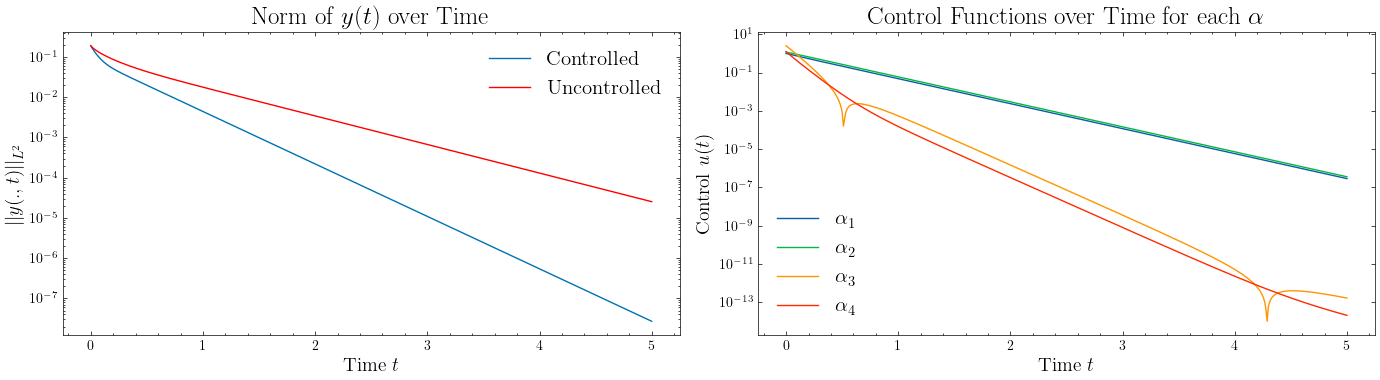

In [38]:
solver = McKeanVlasovSolver(L=50, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000)
plotter = McKeanVlasovPlotter(solver)
plotter.plot_control_and_norm(t_max=5.0, name='../images/polynomial_example_control_vs_uncontrol_small_beta.pdf')

## Kuramoto model

Consider $G(x) = 0$ and $W(x) = -K \cos(x)$.

In [8]:
G = lambda x: np.zeros_like(x)
W = lambda K: lambda x: -K*np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

Initially, consider the case where $K  \le 1$.

In [51]:
solver1 = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=1), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

plotter1 = McKeanVlasovPlotter(solver1)

solver2 = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=0.5), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

plotter2 = McKeanVlasovPlotter(solver2)

solver3 = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=0.1), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

plotter3 = McKeanVlasovPlotter(solver3)

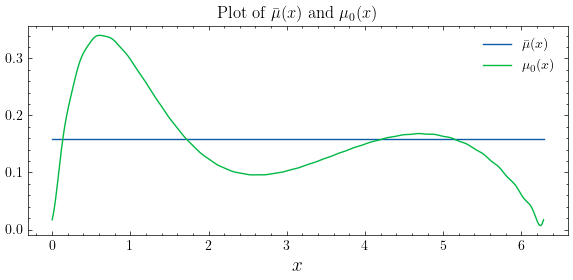

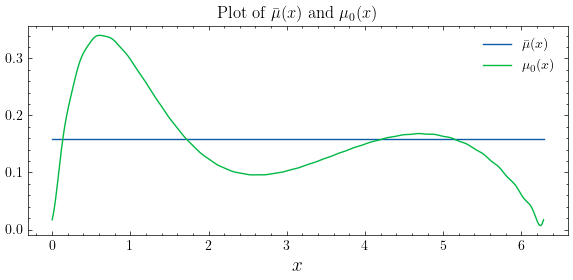

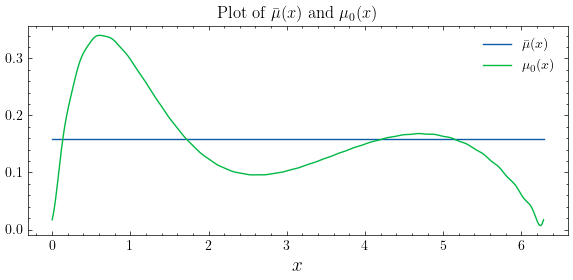

In [53]:
plotter1.plot_mu_bar_x(name="../images/kuramoto_example_steady_state_K_1.pdf")
plotter2.plot_mu_bar_x(name="../images/kuramoto_example_steady_state_K_0-5.pdf")
plotter3.plot_mu_bar_x(name="../images/kuramoto_example_steady_state_K_0-1.pdf")

Now, consider the case where $K > 1$. For that, we have to compute the unique $r > 0$ that defines the second distribution (up to translation).

In [9]:
def unique_r(K):
    """
    Calculate the first cosine Fourier coefficient of q_hat.
    """
    if K <= 1:
        return 0.0
    psi = lambda x: bessel(1, x) / bessel(0, x)
    func = lambda r: r - psi(2 * K * r)
    # We know that when K > 1, r(K) in (sqrt(1 - 1/K), sqrt(1 - 1/2K)), see equation (2.4).
    r = brentq(func, a=np.sqrt(1 - 1/K), b=np.sqrt(1 - 1/(2*K)))
    return r

With that function, we can define the second distribution.

In [19]:
Z = lambda K: np.trapezoid(np.exp(2*K*unique_r(K)*np.cos(x-np.pi)), x)
desired_distribution = lambda K: lambda x: np.exp(2*K*unique_r(K)*np.cos(x-np.pi)) / Z(K)
bar_mu_initial = lambda K: FourierUtils(L=100, d=2*np.pi, min_fourier_samples=5000).project_function(func=desired_distribution(K))

Now we can run our instances. 

In [87]:
solver1 = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=1.5), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, bar_mu_k_initial=bar_mu_initial(K=1.5))

plotter1 = McKeanVlasovPlotter(solver1)

solver2 = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=3), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, bar_mu_k_initial=bar_mu_initial(K=3))

plotter2 = McKeanVlasovPlotter(solver2)

solver3 = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=10), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, bar_mu_k_initial=bar_mu_initial(K=10))

plotter3 = McKeanVlasovPlotter(solver3)

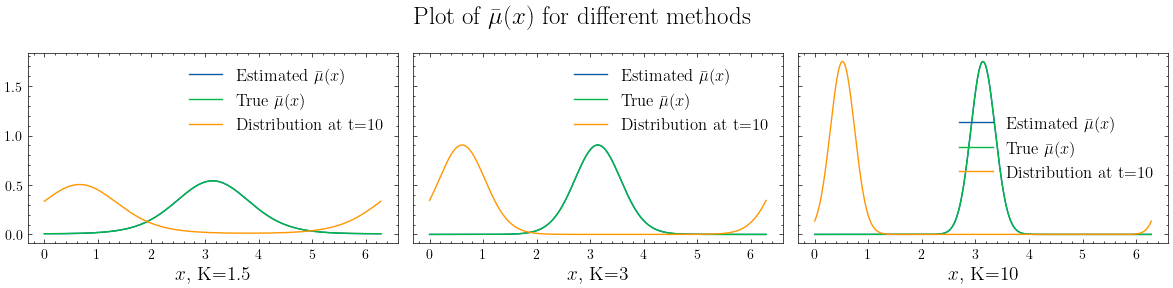

In [104]:
x = np.linspace(0, solver1.d, 1000)
mu_bar1 = solver1.reconstruction(solver1.bar_mu_k, x)
mu_bar2 = solver2.reconstruction(solver2.bar_mu_k, x)
mu_bar3 = solver3.reconstruction(solver3.bar_mu_k, x)

t_max = 10
sol = solver1.nonlinear_uncontrolled_solver_mu(t_span=(0,t_max), t_eval=(t_max,))
final_distribution1 = solver1.reconstruction(sol.y[:,0], x)
sol = solver2.nonlinear_uncontrolled_solver_mu(t_span=(0,t_max), t_eval=(t_max,))
final_distribution2 = solver2.reconstruction(sol.y[:,0], x)
sol = solver3.nonlinear_uncontrolled_solver_mu(t_span=(0,t_max), t_eval=(t_max,))
final_distribution3 = solver3.reconstruction(sol.y[:,0], x)

fig, ax = plt.subplots(1,3,figsize=(12,3), sharey=True)

ax[0].plot(x, mu_bar1, label=r'Estimated $\bar{\mu}(x)$')
ax[0].plot(x, desired_distribution(K=1.5)(x), label=r'True $\bar{\mu}(x)$')
ax[0].plot(x, final_distribution1, label=r'Distribution at t={}'.format(t_max))
ax[0].set_xlabel('$x$, K=1.5', fontsize=14)
ax[0].legend(fontsize=12)

ax[1].plot(x, mu_bar2, label=r'Estimated $\bar{\mu}(x)$')
ax[1].plot(x, desired_distribution(K=3)(x), label=r'True $\bar{\mu}(x)$')
ax[1].plot(x, final_distribution2, label=r'Distribution at t={}'.format(t_max))
ax[1].set_xlabel('$x$, K=3', fontsize=14)
ax[1].legend(fontsize=12)

ax[2].plot(x, mu_bar3, label=r'Estimated $\bar{\mu}(x)$')
ax[2].plot(x, desired_distribution(K=10)(x), label=r'True $\bar{\mu}(x)$')
ax[2].plot(x, final_distribution3, label=r'Distribution at t={}'.format(t_max))
ax[2].set_xlabel('$x$, K=10', fontsize=14)
ax[2].legend(fontsize=12)

fig.suptitle(r'Plot of $\bar{\mu}(x)$ for different methods', fontsize=18)
fig.tight_layout()

fig.savefig("../images/kuramoto_example_steady_state_K>1.pdf", format='PDF', bbox_inches='tight')

### Spectral gap analysis (incomplete) 

Now we analyze the spectral gap. 

In [13]:
def spectral_gap_bound(K):
    """
    Calculate the spectral gap lower bound given by equation (1.25) of 
    Bertini, Giacomin, and Pakdaman (2009).
    """
    if K <= 1:
        return 0.0
    r = unique_r(K)
    I_0 = bessel(0, 2*K*r)
    I_0_squared = I_0**2
    
    exp_4Kr = np.exp(4 * K * r)
    exp_8Kr = exp_4Kr**2
    
    scaled_numerator = (1 - K * (1 - r*r)) / exp_4Kr
    scaled_denominator = 2 * K * r*r / (1 - 1/I_0_squared) * exp_4Kr + 1
    
    return scaled_numerator / scaled_denominator

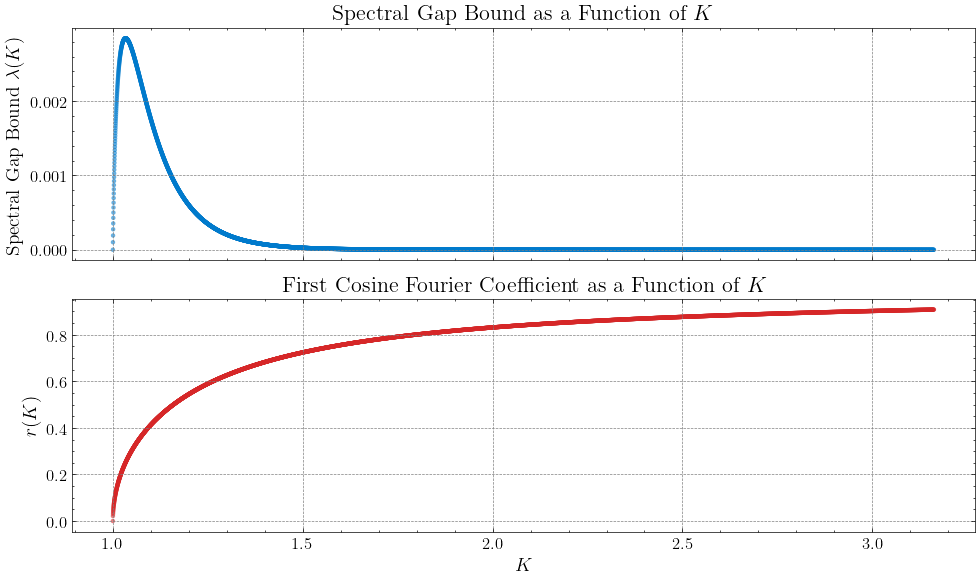

In [14]:
K_values = np.logspace(0.0, 0.5, 5000)
spectral_values = [spectral_gap_bound(K) for K in K_values]
r_values = [unique_r(K) for K in K_values]

fig, ax = plt.subplots(2,1, figsize=(10, 6), sharex=True)
ax[0].scatter(K_values, spectral_values, s=10, alpha=0.6, color="#007acc", edgecolors='none')
ax[0].set_title('Spectral Gap Bound as a Function of $K$', fontsize=16, weight='bold')
#ax[0].set_xlabel('$K$', fontsize=14)
ax[0].set_ylabel('Spectral Gap Bound $\lambda(K)$', fontsize=14)
ax[0].tick_params(axis='both', labelsize=12)
ax[0].grid(ls="--", c='grey')

ax[1].scatter(K_values, r_values, s=10, alpha=0.6, color="#d62728", edgecolors='none')
ax[1].set_title('First Cosine Fourier Coefficient as a Function of $K$', fontsize=16, weight='bold')
ax[1].set_xlabel('$K$', fontsize=14)
ax[1].set_ylabel('$r(K)$', fontsize=14)
ax[1].tick_params(axis='both', labelsize=12)
ax[1].grid(ls="--", c='grey')
fig.tight_layout()

fig.savefig('../images/kuramoto_example_spectral_gap_lb.pdf', format='PDF', bbox_inches='tight')
plt.show()

Notice that our discretization is not symmetric as we observed theoretically because we are using a different inner product.

In [15]:
def compute_M(func, d, L, N):
    # Create uniform grid and evaluate f(x)
    x = np.linspace(0, d, N)
    f_vals = func(x)
    dx = d / N

    # Fourier mode indices and number of modes
    k_vals = np.arange(-L, L+1)
    n_modes = len(k_vals)
    
    # Initialize primitives U_k on the grid
    U = np.zeros((n_modes, N), dtype=complex)
    for idx, k in enumerate(k_vals):
        if k == 0:
            # For the zero mode, set the primitive to 0
            U[idx, :] = 0.0
        else:
            U[idx, :] = np.sqrt(d) / (2 * np.pi * 1j * k) * np.exp(2 * np.pi * 1j * k * x / d)
    
    # Build the Gram matrix M in H_{-1,1/f}
    M = np.zeros((n_modes, n_modes), dtype=complex)
    for i in range(n_modes):
        for j in range(n_modes):
            # Use the weighted inner product: conjugate(U_i)*U_j/f
            integrand = np.conjugate(U[i, :]) * U[j, :] / f_vals
            M[i, j] = np.sum(integrand) * dx
            
    return 0.5*(M+np.conjugate(M.T))

def compute_L_H_minus1(M, K):
    zero = M.shape[0] // 2  # index of zero mode (k = 0)
    idx = np.delete(np.arange(M.shape[0]), zero)  # remove zero mode index
    M_reduced = M[np.ix_(idx, idx)]
    K_reduced =  K[np.ix_(idx, idx)]
    L_tilde = M_reduced @ K_reduced
    
    L = np.zeros_like(K, dtype=complex)
    L[np.ix_(idx, idx)] = L_tilde
    return L

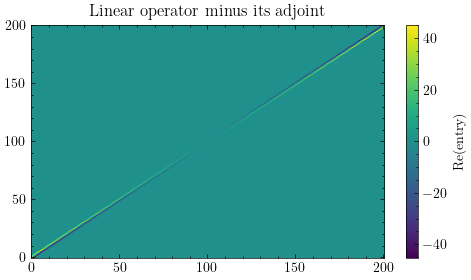

In [65]:
K = 1.1
solver = McKeanVlasovSolver(L=100, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=K), mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, 
                            final_distribution=FourierUtils(L=100, 
                                                            d=2*np.pi, 
                                                            min_fourier_samples=5000).project_function(desired_distribution(K=K)))
linear_operator = -(solver.L_G + solver.K + solver.sigma * solver.D)

plt.figure(figsize=(5, 3))
plt.imshow(np.real(linear_operator - np.conjugate(linear_operator.T)), cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(label='Re(entry)')
plt.title('Linear operator minus its adjoint')
plt.tight_layout()
plt.savefig('../images/kuramoto_example_linear_matrix.pdf', format="PDF", bbox_inches='tight')
plt.show()

In [66]:
M = compute_M(desired_distribution(K=K), d=solver.d, L=solver.L, N=50000)
linear_operator_symmetric = compute_L_H_minus1(M, linear_operator)
eigenvalues, eigenvectors = eig(linear_operator_symmetric)

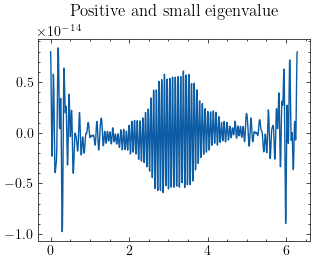

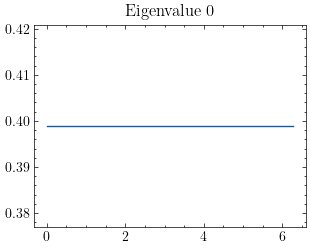

In [67]:
plt.plot(x, solver.reconstruction(eigenvectors[:,0], x))
plt.title("Positive and small eigenvalue")
plt.show()
plt.title("Eigenvalue 0")
plt.plot(x, solver.reconstruction(eigenvectors[:,-1], x))
plt.show()

Let us see what happens for more values.

In [20]:
spectral_gap_values = []
x = np.linspace(0, 2*np.pi, 1000)

solver = McKeanVlasovSolver(L=100, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=1), mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, bar_mu_k_initial=bar_mu_initial(K=1))

for K in tqdm(np.linspace(1, 3, 30)):
    solver = McKeanVlasovSolver(L=100, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W(K=K), mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, bar_mu_k_initial=bar_mu_initial(K=K))
    
    linear_operator = -(solver.L_G + solver.K + solver.sigma * solver.D)
    M = compute_M(desired_distribution(K=K), d=solver.d, L=solver.L, N=50000)
    linear_operator_symmetric = compute_L_H_minus1(M, linear_operator)
    eigenvalues, _ = eig(linear_operator_symmetric)
    sorted_indices = np.argsort(eigenvalues.real)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]

    spectral_gap_values.append(abs(sorted_eigenvalues[1].real))

100%|███████████████████████████████████████████| 30/30 [07:27<00:00, 14.92s/it]


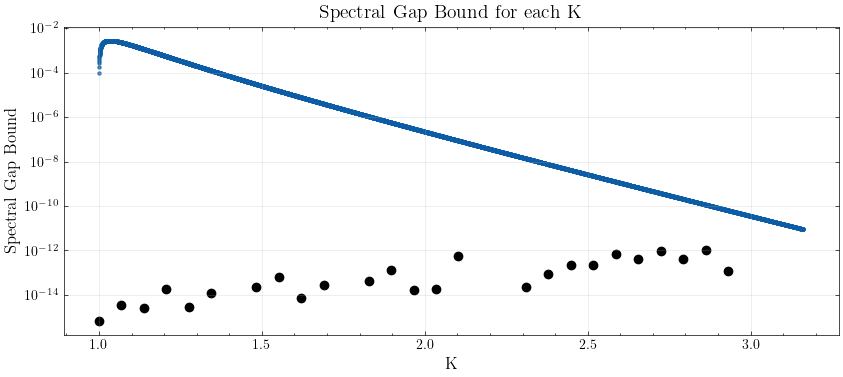

In [21]:
plt.figure(figsize=(10, 4))
plt.scatter(K_values, spectral_values, s=5, alpha=0.7)
plt.scatter(np.linspace(1, 3, 30), spectral_gap_values, color="black")
plt.title('Spectral Gap Bound for each K', fontsize=14)
plt.xlabel('K', fontsize=12)
plt.yscale('log')
plt.ylabel('Spectral Gap Bound', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Controlling the equation

For $K=5$, the situation is different. There is the presence of a second stationary distribution and the uniform one turns out to be unstable. Let's see what is means to linearise around the **unstable** steady state. 

In [44]:
G = lambda x: np.zeros_like(x)
W1 = lambda x: -0.95*np.cos(x)
W2 = lambda x: -5*np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

solver1 = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W1, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

solver2 = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W2, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5)

t_max = 5
solution1_c = solver1.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, max(500, int(np.ceil(t_max * 100)))))
solution1_u = solver1.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, max(500, int(np.ceil(t_max * 100)))))
solution2_c = solver2.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, max(500, int(np.ceil(t_max * 100)))))
solution2_u = solver2.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, max(500, int(np.ceil(t_max * 100)))))

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.23 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.23 seconds.


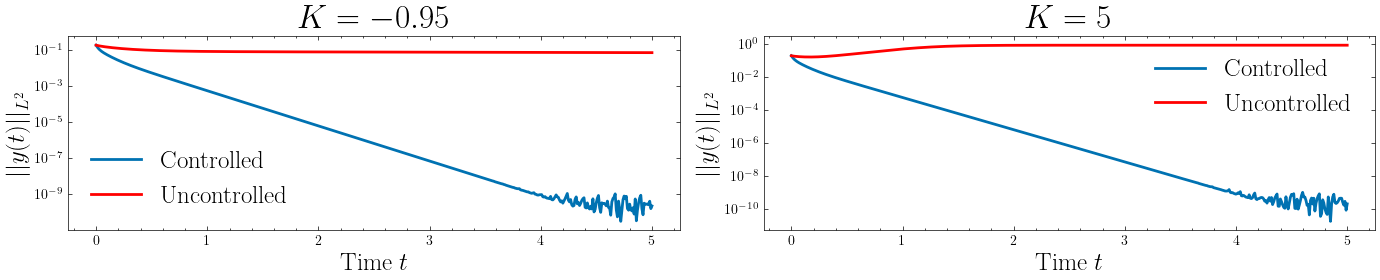

In [45]:
t1 = solution1_c.t
y_norm1_c = np.linalg.norm(solution1_c.y, axis=0)
y_norm1_u = np.linalg.norm(solution1_u.y, axis=0)

# Compute time points and L^2 norms for Example 2 (K = 5)
t2 = solution2_c.t
y_norm2_c = np.linalg.norm(solution2_c.y, axis=0)
y_norm2_u = np.linalg.norm(solution2_u.y, axis=0)

# Create a figure with two subplots arranged side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 3))

# Plot for Example 1 (K = -0.95)
ax1.plot(t1, y_norm1_c, label="Controlled", color="#0072B2", linewidth=2)
ax1.plot(t1, y_norm1_u, label="Uncontrolled", color="red", linewidth=2)
ax1.set_xlabel("Time $t$", fontsize=18)
ax1.set_ylabel("$||y(t)||_{L^2}$", fontsize=18)
ax1.set_title(r"$K = -0.95$", fontsize=24)
ax1.set_yscale("log")
ax1.legend(fontsize=18)

# Plot for Example 2 (K = 5)
ax2.plot(t2, y_norm2_c, label="Controlled", color="#0072B2", linewidth=2)
ax2.plot(t2, y_norm2_u, label="Uncontrolled", color="red", linewidth=2)
ax2.set_xlabel("Time $t$", fontsize=18)
ax2.set_ylabel("$||y(t)||_{L^2}$", fontsize=18)
ax2.set_title(r"$K = 5$", fontsize=24)
ax2.set_yscale("log")
ax2.legend(fontsize=18)

plt.tight_layout()
plt.savefig("../images/fig_cnmac2025.pdf", bbox_inches="tight")
plt.show()

### Interesting aspect

We know that for a given initial distribution, if $K > 1$, we are going to converge to a distribution which is proportional to a translation of $\exp(2Kr\cos(x))$. The question is: can we force to other stationary distribution? 

In [308]:
K = 2
desired_distribution_alpha = lambda K: lambda x, alpha=0.0: np.exp(2*K*unique_r(K)*np.cos(x-alpha)) / Z(K)
a = solver.fourier.project_function(func=desired_distribution_alpha(K=K))

In [309]:
G = lambda x: np.zeros_like(x)
W = lambda x: -K*np.cos(x)

initial_distribution = lambda x: mu_0_mixed(x, a1=2.0, b1=2.0, a2=2.0, b2=2.0)

solver = McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=initial_distribution, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=1000, sigma=0.5, final_distribution=a)

MESSAGE - Nonlinear equation solved in 2.26 seconds.


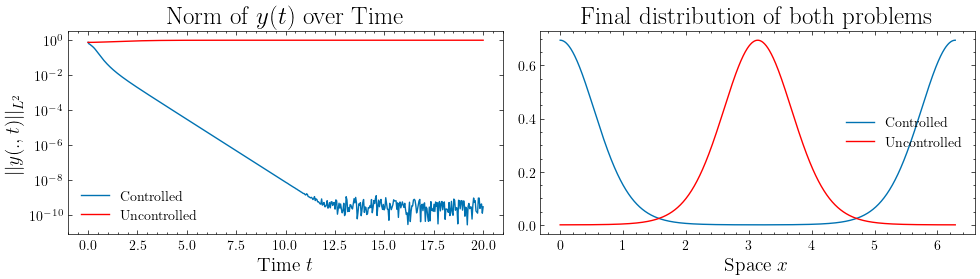

In [311]:
solution = solver.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
solution_uncontrolled = solver.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

t_points = solution.t
control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

y_norm = np.linalg.norm(solution.y, axis=0)
y_norm2 = np.linalg.norm(solution_uncontrolled.y, axis=0)

# Creating the subplot figure
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

# Plotting ||y(., t)||_{L^2} over time
ax1.plot(t_points, y_norm, color="#0072B2", label="Controlled")
ax1.plot(t_points, y_norm2, color="red", label="Uncontrolled")
ax1.set_xlabel('Time $t$', fontsize=14)
ax1.set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax1.set_title('Norm of $y(t)$ over Time', fontsize=18)
ax1.set_yscale("log")
ax1.legend()

ax2.plot(x, solver.reconstruction(solution.y[:,-1] + a, x), label="Controlled", color="#0072B2")
ax2.plot(x, solver.reconstruction(solution_uncontrolled.y[:,-1] + a, x), label="Uncontrolled", color="red")
ax2.set_xlabel('Space $x$', fontsize=14)
ax2.set_title('Final distribution of both problems', fontsize=18)
ax2.legend()

plt.savefig("../images/kuramoto_example_changing_mode.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

### Changing the values of K

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.02 seconds.
MESSAGE - Nonlinear equation solved in 0.62 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.59 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.60 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.60 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.62 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAG

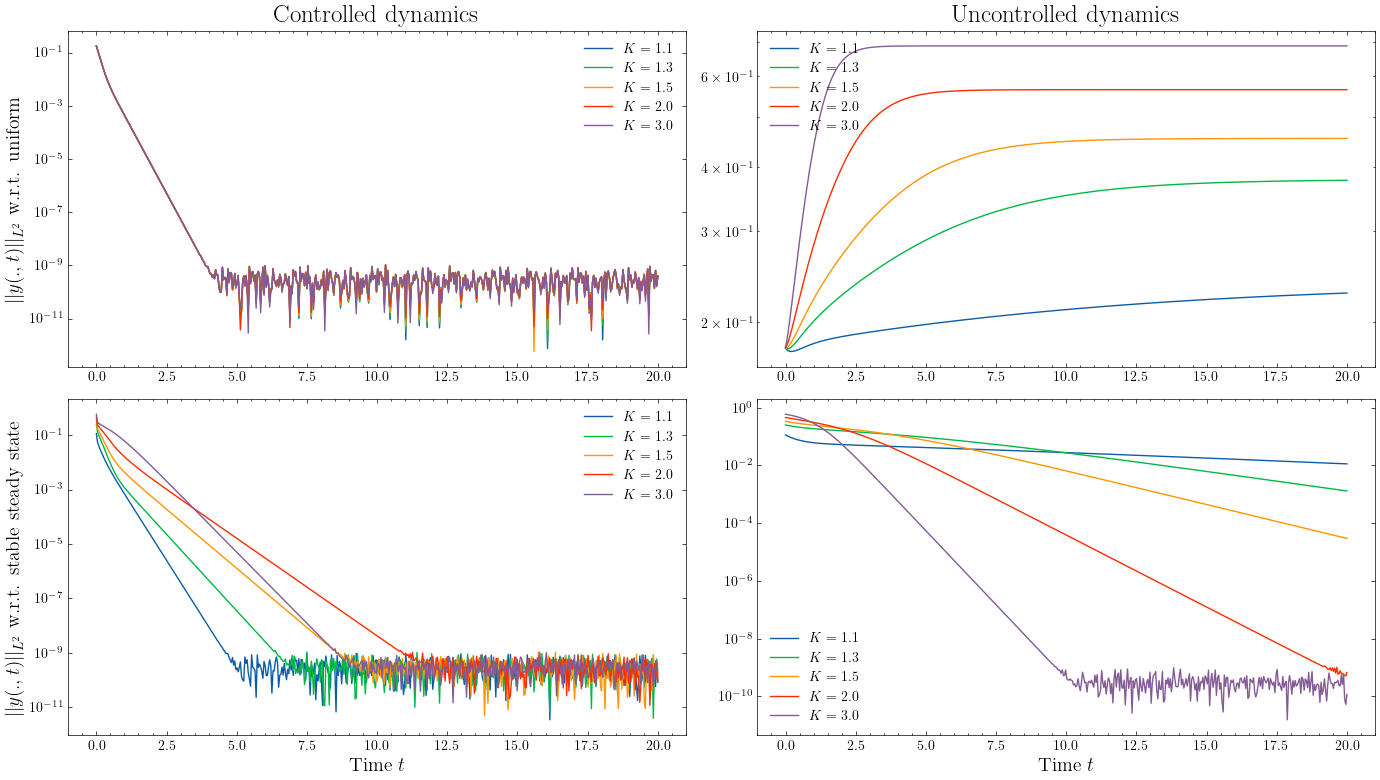

In [322]:
_, ax = plt.subplots(2, 2, figsize=(14, 8))

K_values = [1.1, 1.3, 1.5, 2.0, 3.0]

for index, K in enumerate(K_values):

    # Control to the uniform distribution
    solver1 = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=lambda x: -K*np.cos(x), mu_0=initial_distribution, min_fourier_samples=2000, delta=-0.0001, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5)

    # Control to the stable distribution
    a = solver1.fourier.project_function(func=desired_distribution(K))
    
    solver2 = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=lambda x: -K*np.cos(x), mu_0=initial_distribution, min_fourier_samples=2000, delta=-0.0001, 
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=1000, sigma=0.5, 
                                final_distribution=a)

    solution1 = solver1.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
    solution_uncontrolled1 = solver1.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

    solution2 = solver2.solve_control_problem(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))
    solution_uncontrolled2 = solver2.nonlinear_uncontrolled_solver_y(t_span=(0, 20.0), t_eval=np.linspace(0, 20.0, 500))

    y_norm1 = np.linalg.norm(solution1.y, axis=0)
    y_norm_uncontrolled1 = np.linalg.norm(solution_uncontrolled1.y, axis=0)

    y_norm2 = np.linalg.norm(solution2.y, axis=0)
    y_norm_uncontrolled2 = np.linalg.norm(solution_uncontrolled2.y, axis=0)

    ax[0,0].plot(t_points, y_norm1, label=r"$K$ = {}".format(K))
    ax[0,1].plot(t_points, y_norm_uncontrolled1, label=r"$K$ = {}".format(K))
    ax[1,0].plot(t_points, y_norm2, label=r"$K$ = {}".format(K))
    ax[1,1].plot(t_points, y_norm_uncontrolled2, label=r"$K$ = {}".format(K))
    
ax[1,0].set_xlabel('Time $t$', fontsize=14)
ax[1,1].set_xlabel('Time $t$', fontsize=14)
ax[0,0].set_ylabel('$||y(., t)||_{L^2}$ w.r.t. uniform', fontsize=14)
ax[1,0].set_ylabel('$||y(., t)||_{L^2}$ w.r.t. stable steady state', fontsize=14)
ax[0,0].set_title('Controlled dynamics', fontsize=18)
ax[0,1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0,0].set_yscale("log")
ax[0,1].set_yscale("log")
ax[1,0].set_yscale("log")
ax[1,1].set_yscale("log")
ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.savefig("../images/kuramoto_example_changing_K.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()

## Kuramoto model + confining potential G

Let us change the model a little bit to include a non-zero potential $G$. 

$$
G(x) = cos(2x), W(x) = -cos(x)
$$

For $\sigma \ge 0.78$, we expect the single solution to be $\rho(x) = \exp(-cos(2x)/\sigma)$. For $\sigma < 0.77$, we have this solution plus other two with pick being at $\pi/2$ and $3\pi/2$.

Consider the example given in https://arxiv.org/pdf/2211.08004#page=7.23

In [73]:
G = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

x = np.linspace(0, 2*np.pi, 1000)

Consider $\sigma = 0.78$. We expect a slow convergence.

In [95]:
sigmas = [0.78, 0.6]

solvers = [McKeanVlasovSolver(L=30, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000) for sigma in sigmas]

a_bars = [solver.nonlinear_controlled_solver_mu(t_span=(0, 200), t_eval=(100, 200,), u=lambda t,a: np.zeros(4))
          for solver in solvers]

mu_bars = [
    (solvers[idx].reconstruction(solvers[idx].bar_mu_k, x),
     solvers[idx].reconstruction(a_bars[idx].y[:,-2], x),
     solvers[idx].reconstruction(a_bars[idx].y[:,-1], x)
    )
    for idx, _ in enumerate(sigmas)
]

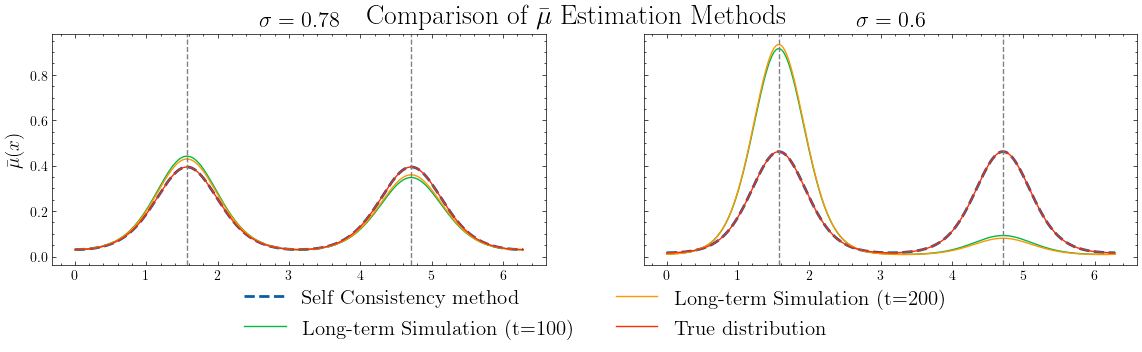

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharey=True)

for ax, sigma_val, (mu1, mu3_1, mu3_2) in zip(axes, sigmas, mu_bars):
    ax.plot(x, mu1, label="Self Consistency method", ls='--', lw=2)
    ax.plot(x, mu3_1, label="Long-term Simulation (t=100)")
    ax.plot(x, mu3_2, label="Long-term Simulation (t=200)")
    
    # True distribution for this sigma
    true_dist = np.exp(-np.cos(2*x)/sigma_val)
    true_dist /= np.trapezoid(true_dist, x)
    ax.plot(x, true_dist, label="True distribution")

    ax.axvline(2*np.pi - np.pi/2, ls="--", c="gray")
    ax.axvline(np.pi/2, ls="--", c="gray")
    ax.set_title(rf"$\sigma = {sigma_val}$", fontsize=16)

axes[0].set_ylabel(r"$\bar{\mu}(x)$", fontsize=14)
axes[0].legend(loc="lower center", bbox_to_anchor=(1.1, -0.4), ncol=2, fontsize=15)
fig.suptitle(r"Comparison of $\bar{\mu}$ Estimation Methods", fontsize=20)
fig.savefig('../images/kuramoto_potential_example_steady_state.pdf', bbox_inches="tight")
plt.show()

### Adding the controller

In [100]:
G = lambda x: np.cos(2 * x)
W = lambda x: -np.cos(x)

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

sigma_values = [0.77, 0.79, 0.81, 0.83, 0.85]

t_max = 50

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.02 seconds.
MESSAGE - Nonlinear equation solved in 4.06 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 3.86 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 3.76 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 3.72 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 3.72 seconds.


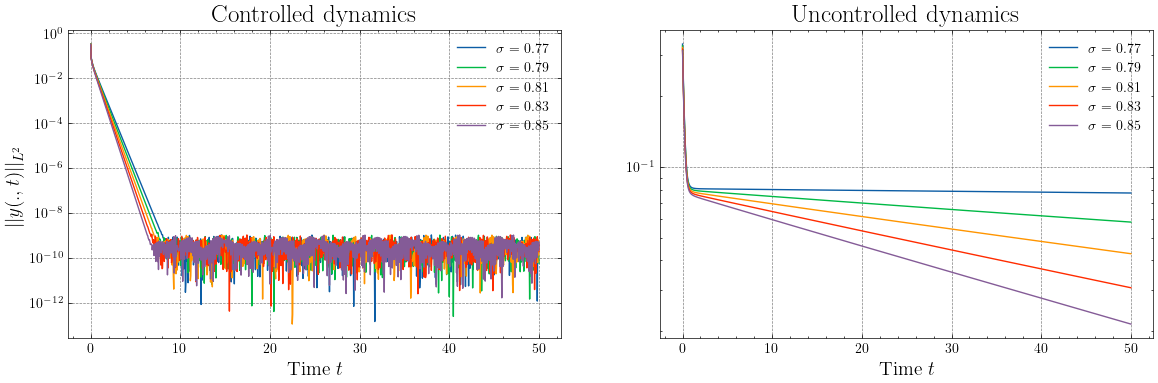

In [101]:
_, ax = plt.subplots(1, 2, figsize=(14, 4))

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)


    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    ax[0].grid(ls="--", color='grey')
    ax[1].grid(ls="--", color='grey')
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[1].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.savefig("../images/kuramoto_potential_control_different_sigmas.pdf", bbox_inches='tight')
plt.show()

We covered the accelerate to the steady state part. Now we are also interested when the distribution is converging to other distribution.

As we discussed, when $\sigma < 0.77$ (even for $\sigma = 0.769$ we are apparently converging to other distribution), we have the case where $\rho(x) = \exp(-cos(2x)/\sigma)$ is a solution but we got other stationary distribution.

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 5.23 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.53 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.12 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 3.96 seconds.


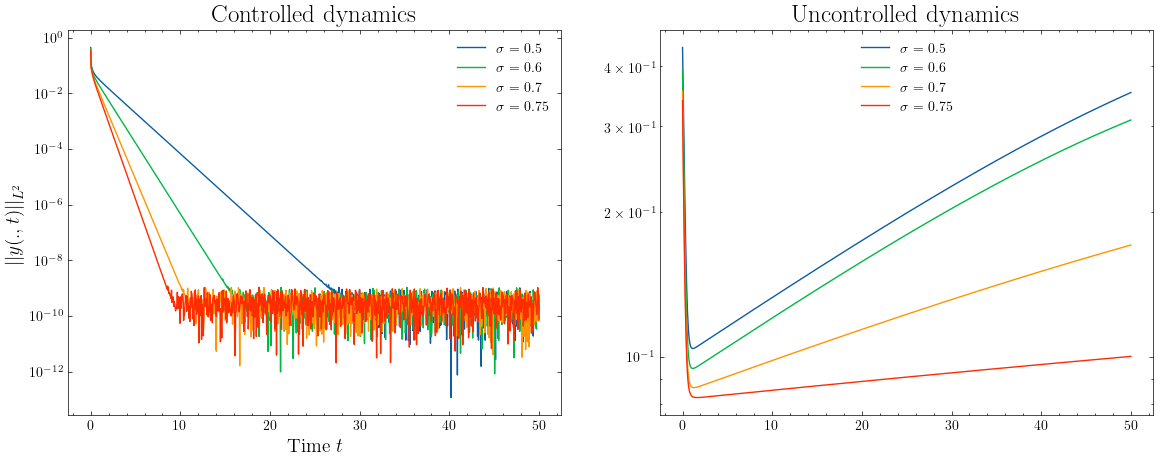

In [61]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

sigma_values = [0.5, 0.6, 0.7, 0.75]

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)

    C = solver.fourier.integrate(f=lambda x: np.exp(-np.cos(2*x)/sigma), n_points=2000)
    final_distribution = solver.fourier.project_function(func=lambda x: np.exp(-np.cos(2*x)/sigma) / C)

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000, final_distribution=final_distribution)

    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.show()

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 9.03 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 7.16 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 5.47 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 4.40 seconds.


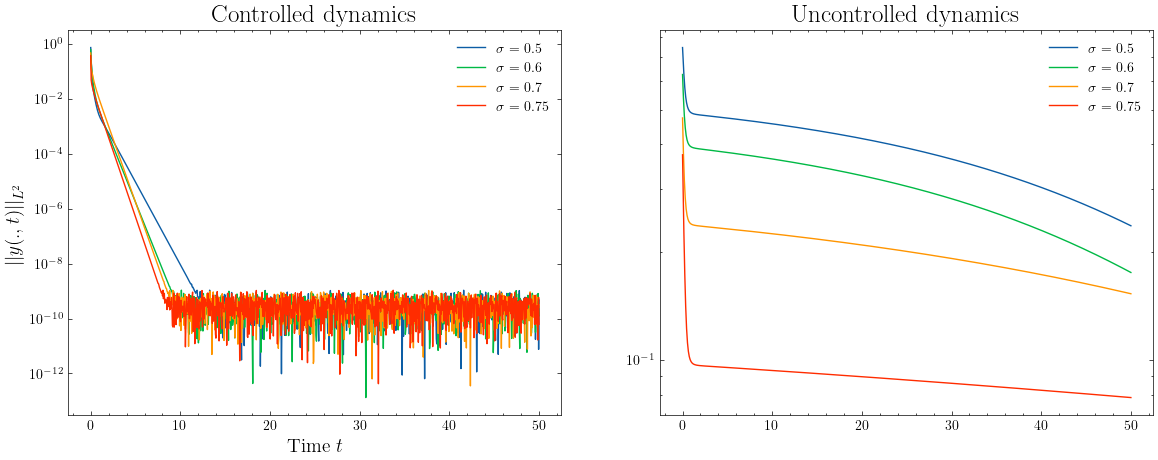

In [62]:
_, ax = plt.subplots(1, 2, figsize=(14, 5))

sigma_values = [0.5, 0.6, 0.7, 0.75]
t_max = 50

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)
    
    final_time = 1000
    while True:
        mu = solver.nonlinear_uncontrolled_solver_mu(t_span=(0, final_time), t_eval=(final_time/2, final_time))
        if np.linalg.norm(mu.y[:,-2] - mu.y[:,-1]) < 1e-6:
            break
        else:
            final_time *= 2

    final_distribution = mu.y[:,-1]
    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000, final_distribution=final_distribution)

    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.show()

## O(2) model with magnetic field

Now we consider a different model over $[0,1]$:

$G(x) = -\eta cos(2\pi x), W(x) = -cos(2\pi x)$.  

In [63]:
eta = 0.05
G = lambda x: -eta * np.cos(2 * np.pi * x)
W = lambda x: -np.cos(2 * np.pi * x)
sigma = 0.4678 # close to threshold
d = 1
    
solver = McKeanVlasovSolver(L=20, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

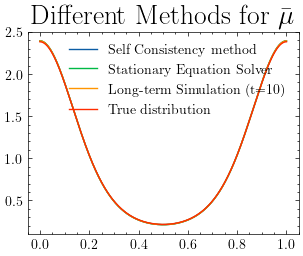

In [64]:
x = np.linspace(0, d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation", bar_mu_k_initial=solver.bar_mu_k[solver.L+1:])
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 10), t_eval=(10,), u=lambda t,a: np.zeros(4))
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
a = 1.2
plt.plot(x, np.exp(a*np.cos(2*np.pi*x)) / np.trapezoid(np.exp(a*np.cos(2*np.pi*x)), x), label="True distribution")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

A small modification over $[0,2\pi]$:

$G(x) = -\eta cos(x), W(x) = -cos(x)$.  

In [65]:
eta = 0.05
G = lambda x: -eta * np.cos(x)
W = lambda x: -np.cos(x)
sigma = 0.4678
d = 2*np.pi
    
solver = McKeanVlasovSolver(L=20, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=5000, delta=-0.001, sigma=sigma,
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

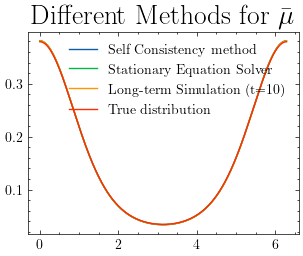

In [66]:
x = np.linspace(0, d, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation", bar_mu_k_initial=solver.bar_mu_k[solver.L+1:])
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 100), t_eval=(100,), u=lambda t,a: np.zeros(4))
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=10)")
a = 1.2
plt.plot(x, np.exp(a*np.cos(x)) / np.trapezoid(np.exp(a*np.cos(x)), x), label="True distribution")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

Another modification: 
$G(x) = -\eta cos(2x), W(x) = -Kcos(x)$.  

In this case, every stationary state has the form 

$$
\rho_{\infty}(x) \propto \exp\left(-\frac{1}{\sigma}(K r_1 \cos(x) + \eta \cos(2x))\right)
$$

In [67]:
eta = 0.5
K = 1.62
G = lambda x: -eta * np.cos(2*x)
W = lambda x: -K * np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

plotter = McKeanVlasovPlotter(solver)

In [68]:
def simulate_mckean_vlasov_torus(eta, K, N=2000, T=20.0, dt=0.01, sigma=1.0, seed=42):
    np.random.seed(seed)
    num_steps = int(T / dt)

    # Initialize particles on [0, 2π)
    X = np.random.uniform(0, 2 * np.pi, N)

    sqrt_2sigma_dt = np.sqrt(2 * sigma * dt)

    for step in tqdm(range(num_steps), desc="Simulating"):
        # Compute gradients
        gradV = 2 * eta * np.sin(2 * X)
        delta = (X[:, None] - X[None, :]+np.pi) % (2 * np.pi) - np.pi
        gradW = K * np.sin(delta)
        sum_gradW = gradW.mean(axis=1)

        # Euler-Maruyama update
        X += (-gradV - sum_gradW) * dt + sqrt_2sigma_dt * np.random.randn(N)
        X %= 2 * np.pi  # Periodic boundary

    return X

final_samples = simulate_mckean_vlasov_torus(eta=eta, K=K)

Simulating: 100%|███████████████████████████| 2000/2000 [01:26<00:00, 23.06it/s]


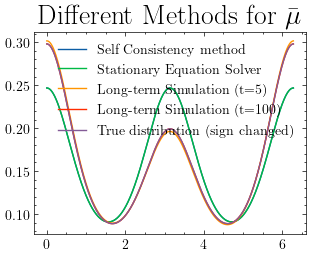

In [69]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 100), t_eval=(5, 100,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

r1 = np.trapezoid(np.cos(x)*mu_bar3_2, x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=5)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=100)")
plt.plot(x, np.exp(K*r1*np.cos(x) + eta*np.cos(2*x)) / np.trapezoid(np.exp(K*r1*np.cos(x) + eta*np.cos(2*x)), x),
         label="True distribution (sign changed)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

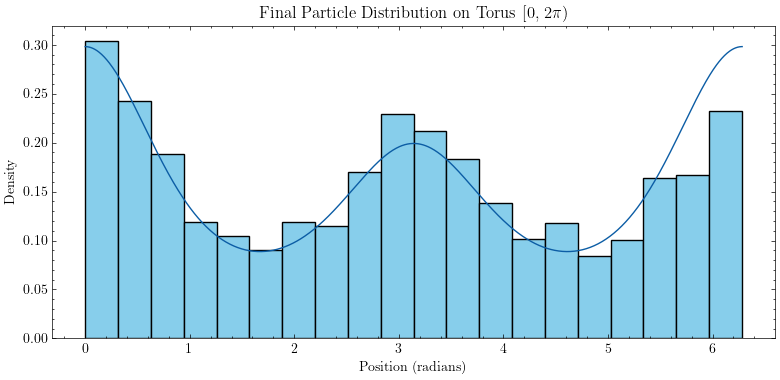

In [70]:
plt.figure(figsize=(8, 4))
plt.hist(final_samples, bins=20, density=True, color='skyblue', edgecolor='black')
plt.plot(x, mu_bar3_2)
plt.title("Final Particle Distribution on Torus [0, $2\pi$)")
plt.xlabel("Position (radians)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [71]:
eta = 0.5
G = lambda x: -eta * np.cos(2*x)
W = lambda x: -1.6*np.cos(x)

solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                            W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.0001, 
                            grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                            state_weight=100000)

plotter = McKeanVlasovPlotter(solver)

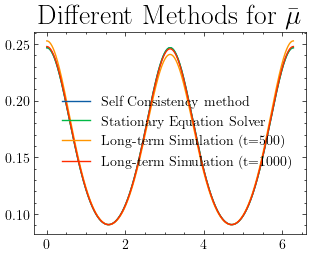

In [72]:
x = np.linspace(0, 2*np.pi, 1000)
mu_bar = solver.reconstruction(solver.bar_mu_k, x)

a_bar2 = solver.compute_bar_mu(method="stationary-equation")
mu_bar2 = solver.reconstruction(a_bar2, x)

a_bar3 = solver.nonlinear_controlled_solver_mu(t_span=(0, 1000), t_eval=(500, 1000,), u=lambda t,a: np.zeros(4))
mu_bar3_1 = solver.reconstruction(a_bar3.y[:,-2], x)
mu_bar3_2 = solver.reconstruction(a_bar3.y[:,-1], x)

plt.plot(x, mu_bar, label="Self Consistency method")
plt.plot(x, mu_bar2, label="Stationary Equation Solver")
plt.plot(x, mu_bar3_1, label="Long-term Simulation (t=500)")
plt.plot(x, mu_bar3_2, label="Long-term Simulation (t=1000)")
plt.title(r"Different Methods for $\bar{\mu}$", fontsize=20)
plt.legend()
plt.show()

In [102]:
eta = 0.05
G = lambda x: -eta * np.cos(2 * np.pi * x)
W = lambda x: -np.cos(2 * np.pi * x)
sigma = 0.4678 # close to threshold
sigma_values = [0.4678, 0.49, 0.53, 0.6]
d = 1
t_max = 5

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 85.51 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 80.65 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 67.27 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.00 seconds.
MESSAGE - Nonlinear equation solved in 54.23 seconds.


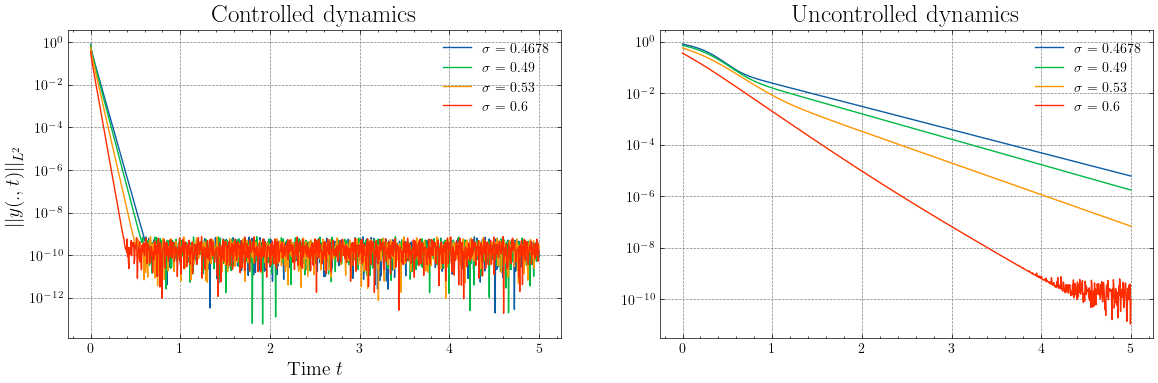

In [104]:
_, ax = plt.subplots(1, 2, figsize=(14, 4))

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=10, d=d, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W, mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)

    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    ax[0].grid(ls="--", color='grey')
    ax[1].grid(ls="--", color='grey')
    
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.savefig("../images/o2_example_control_different_sigmas.pdf", bbox_inches='tight')
plt.show()

## 1d Von Mises interaction potential

In [108]:
G = lambda x: np.zeros_like(x)
W = lambda theta: lambda x: - np.exp(theta * np.cos(x)) / (2*np.pi * bessel(0, theta))

alpha1 = lambda x: np.sin(x)
alpha2 = lambda x: np.cos(x)
alpha3 = lambda x: np.sin(2*x)
alpha4 = lambda x: np.cos(2*x)

nabla_alpha1 = lambda x: np.cos(x)
nabla_alpha2 = lambda x: -np.sin(x)
nabla_alpha3 = lambda x: 2 * np.cos(2*x)
nabla_alpha4 = lambda x: -2 * np.sin(2*x)

x = np.linspace(0, 2*np.pi, 1000)

MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.39 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.35 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 0.39 seconds.
MESSAGE - All conditions satisfied. Matrices are suitable for solving the ARE.
MESSAGE - Riccati equation solved in 0.01 seconds.
MESSAGE - Nonlinear equation solved in 2.68 seconds.


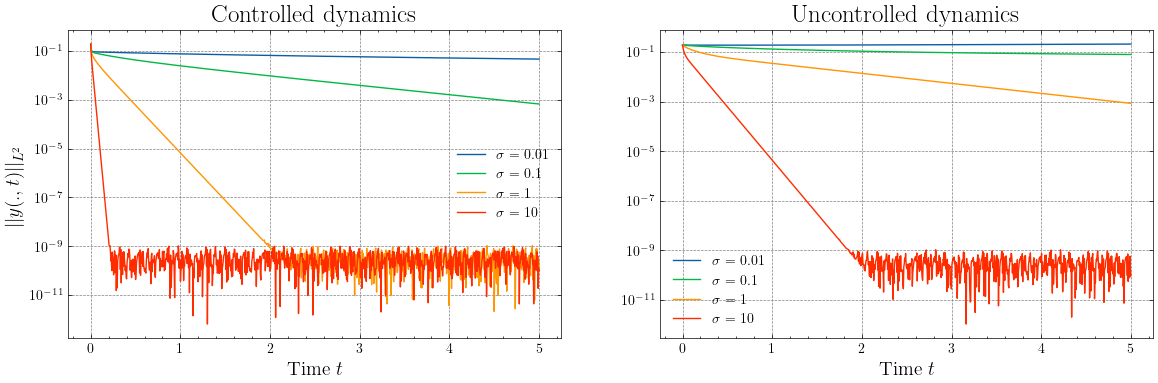

In [111]:
_, ax = plt.subplots(1, 2, figsize=(14, 4))
sigma_values = [0.01, 0.1, 1, 10]

for i, sigma in enumerate(sigma_values):

    solver = McKeanVlasovSolver(L=20, d=2*np.pi, G=G, alpha=[alpha1, alpha2, alpha3, alpha4], 
                                W=W(theta=1), mu_0=mu_0_mixed, min_fourier_samples=2000, delta=-0.001, sigma=sigma,
                                grad_alpha=[nabla_alpha1, nabla_alpha2, nabla_alpha3, nabla_alpha4], 
                                state_weight=100000)

    solution = solver.solve_control_problem(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))
    solution2 = solver.nonlinear_uncontrolled_solver_y(t_span=(0, t_max), t_eval=np.linspace(0, t_max, 1000))

    # Calculate the L^2 norm of y(t)
    y_norm = np.linalg.norm(solution.y, axis=0)
    y_norm2 = np.linalg.norm(solution2.y, axis=0)

    t_points = solution.t
    control = np.array([-np.real(solver.B.conj().T @ solver.Pi @ solution.y[:, i]) for i in range(len(t_points))]).T

    ax[0].plot(t_points, y_norm, label=r"$\sigma$ = {}".format(sigma))
    ax[1].plot(t_points, y_norm2, label=r"$\sigma$ = {}".format(sigma))
    ax[0].grid(ls="--", color='grey')
    ax[1].grid(ls="--", color='grey')
    
ax[0].set_xlabel('Time $t$', fontsize=14)
ax[1].set_xlabel('Time $t$', fontsize=14)
ax[0].set_ylabel('$||y(., t)||_{L^2}$', fontsize=14)
ax[0].set_title('Controlled dynamics', fontsize=18)
ax[1].set_title('Uncontrolled dynamics', fontsize=18)
ax[0].set_yscale("log")
ax[1].set_yscale("log")
ax[0].legend()
ax[1].legend()

plt.savefig("../images/von_mises_control_different_sigmas.pdf", bbox_inches='tight')
plt.show()